In [4]:
# Uvoz biblioteka
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


In [5]:
dCleveland = pd.read_csv(r"../data/processed_cleveland.csv")
dFramingham = pd.read_csv(r"../data/processed_framingham.csv")

In [6]:
# Prvih nekoliko redova
print(dCleveland.head())

# Informacije o kolonama
print(dCleveland.info())

# Statistički rezime
print(dCleveland.describe())

# Provera nedostajućih vrednosti
print(dCleveland.isnull().sum())

# Distribucija ciljne promenljive
print(dCleveland['target'].value_counts())

   age     sex                cp  trestbps  chol  fbs  \
0   63    male    typical angina       145   233  Yes   
1   67    male      asymptomatic       160   286   No   
2   67    male      asymptomatic       120   229   No   
3   37    male  non-anginal pain       130   250   No   
4   41  female   atypical angina       130   204   No   

                        restecg  thalach exang  oldpeak        slope  ca  \
0  left ventricular hypertrophy      150    No      2.3  downsloping   0   
1  left ventricular hypertrophy      108   Yes      1.5         flat   3   
2  left ventricular hypertrophy      129   Yes      2.6         flat   2   
3                        normal      187    No      3.5  downsloping   0   
4  left ventricular hypertrophy      172    No      1.4    upsloping   0   

                thal  target  
0       fixed defect       0  
1  normal blood flow       1  
2  reversible defect       1  
3  normal blood flow       0  
4  normal blood flow       0  
<class 'pandas

In [7]:
# Prvih nekoliko redova
print(dFramingham.head())

# Informacije o kolonama
print(dFramingham.info())

# Statistički rezime
print(dFramingham.describe())

# Provera nedostajućih vrednosti
print(dFramingham.isnull().sum())

# Distribucija ciljne promenljive
print(dFramingham['TenYearCHD'].value_counts())

      sex  age                                        education currentSmoker  \
0  Female   39                      College or higher education            No   
1    Male   46  Some high school (up to 12th grade, no diploma)            No   
2  Female   48                                Elementary school           Yes   
3    Male   61                             High school graduate           Yes   
4    Male   46                             High school graduate           Yes   

   cigsPerDay BPMeds prevalentStroke prevalentHyp diabetes   chol  trestbps  \
0         0.0     No              No           No       No  195.0     106.0   
1         0.0     No              No           No       No  250.0     121.0   
2        20.0     No              No           No       No  245.0     127.5   
3        30.0     No              No          Yes       No  225.0     150.0   
4        23.0     No              No           No       No  285.0     130.0   

   diaBP    BMI  heartRate  glucose  T

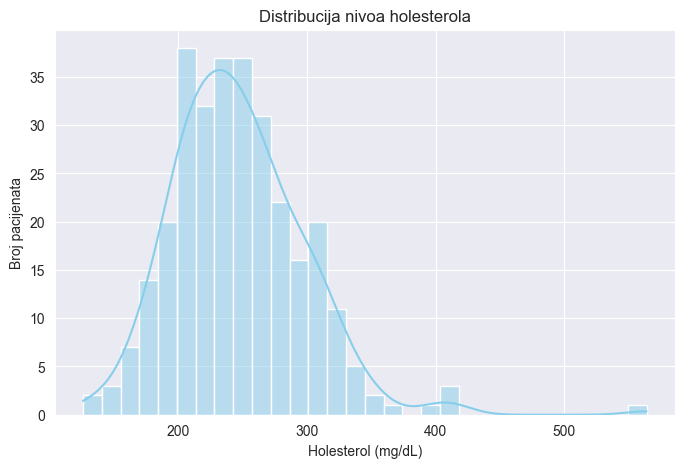

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(dCleveland['chol'], bins=30, kde=True, color='skyblue')
plt.title("Distribucija nivoa holesterola")
plt.xlabel("Holesterol (mg/dL)")
plt.ylabel("Broj pacijenata")
plt.show()

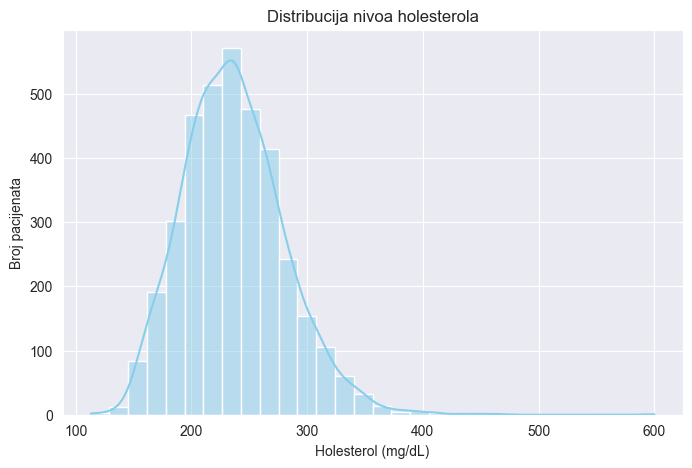

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(dFramingham['chol'], bins=30, kde=True, color='skyblue')
plt.title("Distribucija nivoa holesterola")
plt.xlabel("Holesterol (mg/dL)")
plt.ylabel("Broj pacijenata")
plt.show()

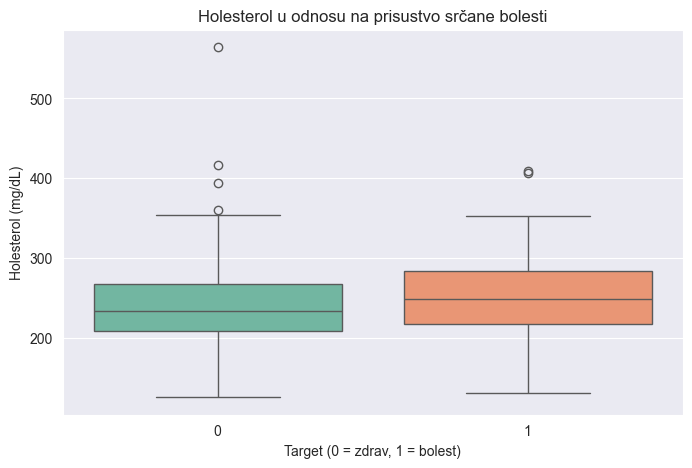

In [15]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    x='target',
    y='chol',
    hue='target',
    data=dCleveland,
    palette='Set2',
    legend=False
)
plt.title("Holesterol u odnosu na prisustvo srčane bolesti")
plt.xlabel("Target (0 = zdrav, 1 = bolest)")
plt.ylabel("Holesterol (mg/dL)")
plt.show()

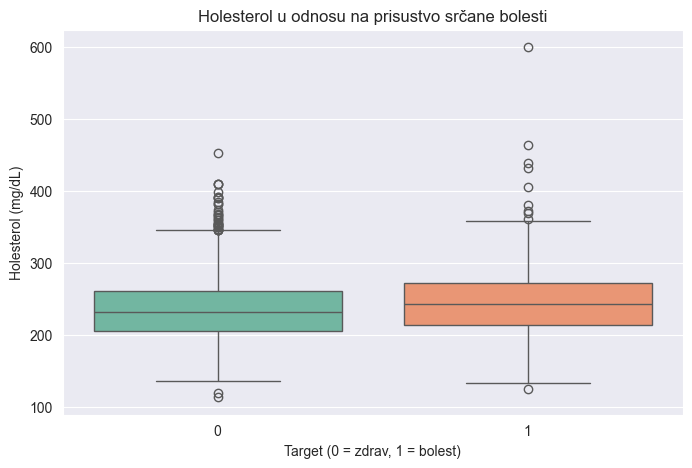

In [18]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='TenYearCHD', y='chol', hue='TenYearCHD', data=dFramingham,
    palette='Set2',
    legend=False)
plt.title("Holesterol u odnosu na prisustvo srčane bolesti")
plt.xlabel("Target (0 = zdrav, 1 = bolest)")
plt.ylabel("Holesterol (mg/dL)")
plt.show()

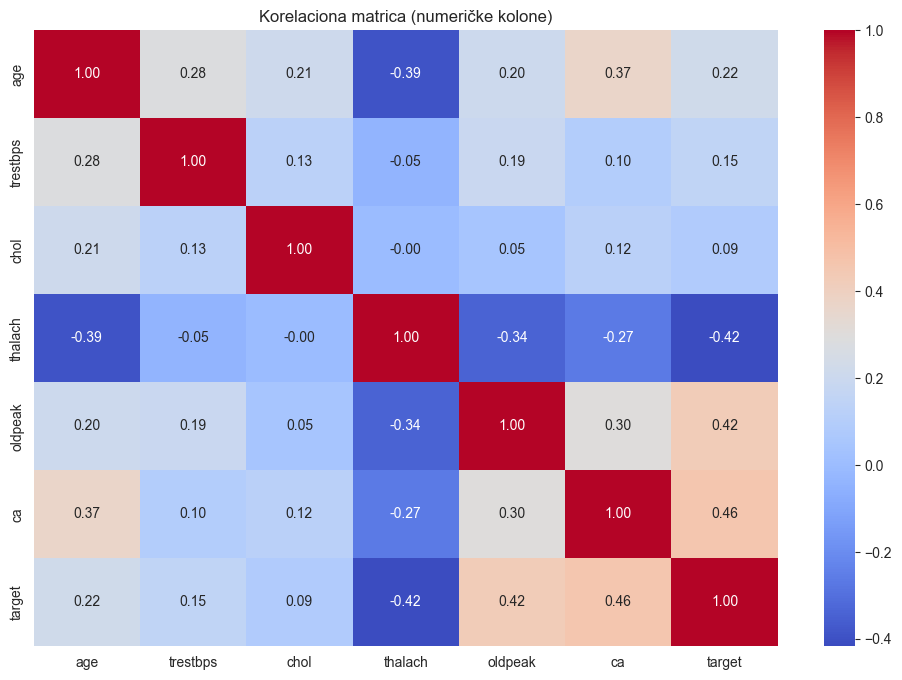

In [25]:
plt.figure(figsize=(12, 8))

num_df = dCleveland.select_dtypes(include=[np.number])
corr = num_df.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Korelaciona matrica (numeričke kolone)")
plt.show()

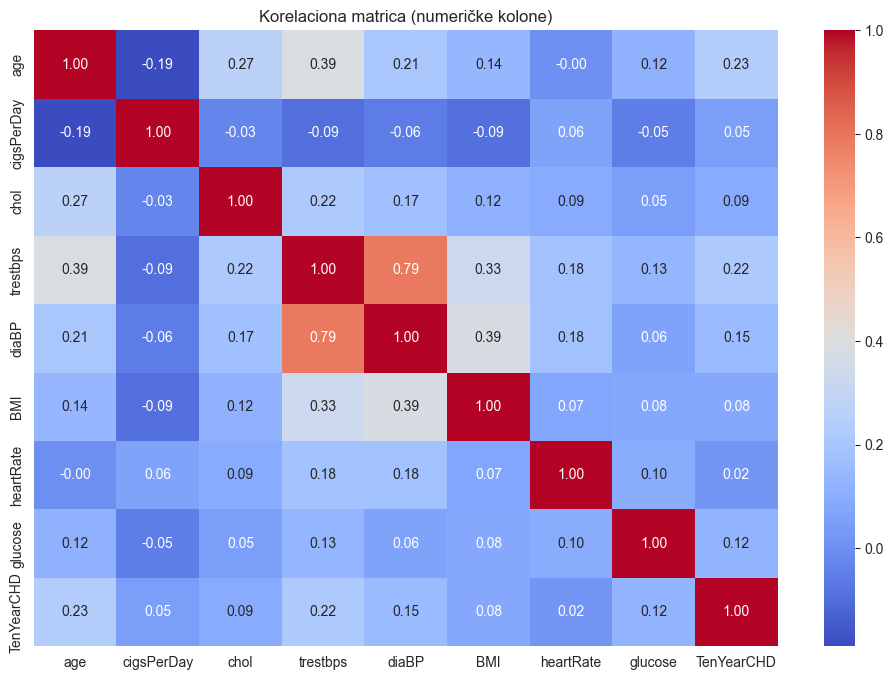

In [26]:
plt.figure(figsize=(12, 8))

num_df = dFramingham.select_dtypes(include=[np.number])
corr = num_df.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Korelaciona matrica (numeričke kolone)")
plt.show()

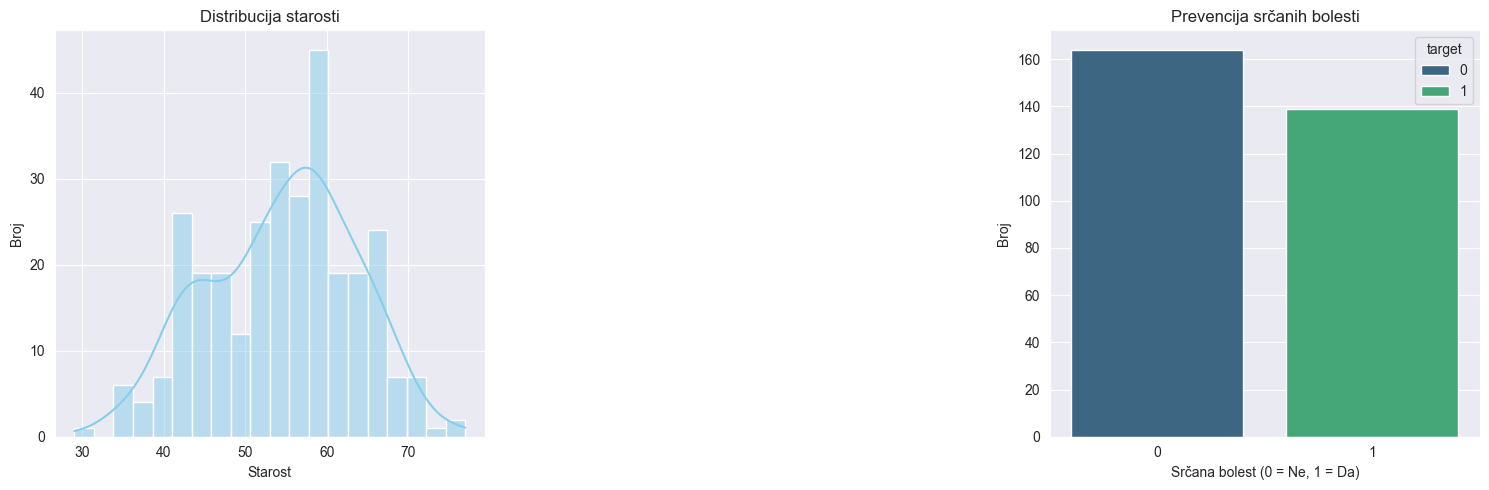

In [30]:
# Vizualizacije
plt.figure(figsize=(15, 5))

# Distribucija starosti
plt.subplot(1, 3, 1)
sns.histplot(dCleveland['age'], bins=20, kde=True, color='skyblue')
plt.title('Distribucija starosti')
plt.xlabel('Starost')
plt.ylabel('Broj')



# Prevalencija srčanih bolesti
plt.subplot(1, 3, 3)
sns.countplot(x='target', data=dCleveland, palette='viridis', hue='target')
plt.title('Distribucija starosti')
plt.title('Prevencija srčanih bolesti')
plt.xlabel('Srčana bolest (0 = Ne, 1 = Da)')
plt.ylabel('Broj')

plt.tight_layout()
plt.show()

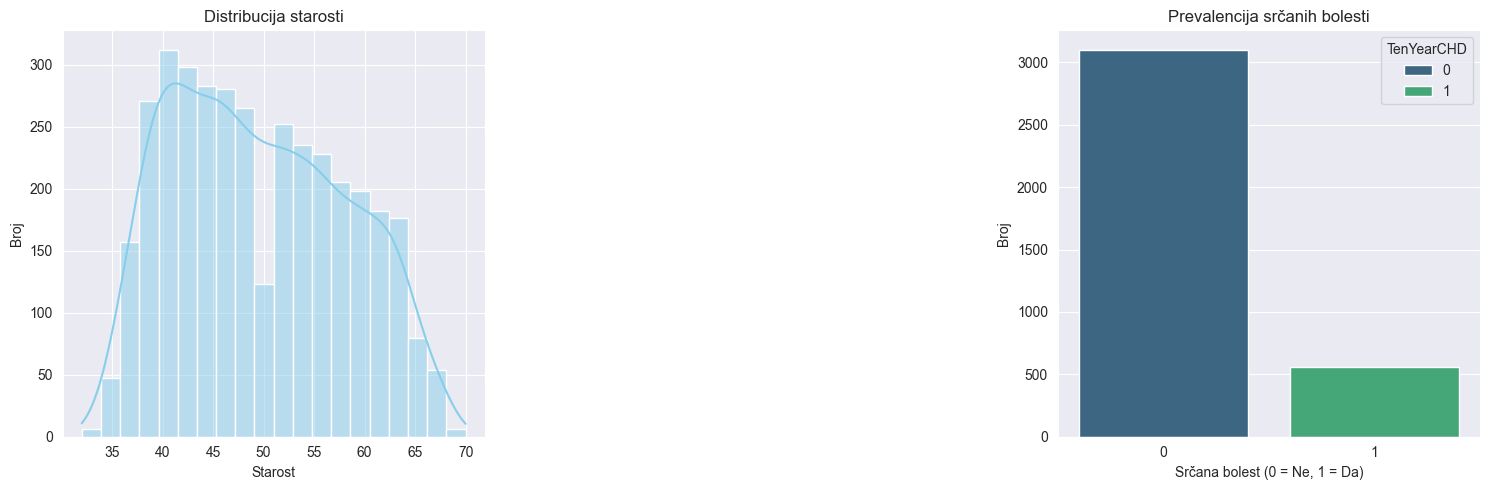

In [31]:
# Vizualizacije
plt.figure(figsize=(15, 5))

# Distribucija starosti
plt.subplot(1, 3, 1)
sns.histplot(dFramingham['age'], bins=20, kde=True, color='skyblue')
plt.title('Distribucija starosti')
plt.xlabel('Starost')
plt.ylabel('Broj')



# Prevalencija srčanih bolesti
plt.subplot(1, 3, 3)
sns.countplot(x='TenYearCHD', data=dFramingham, palette='viridis', hue='TenYearCHD')
plt.title('Prevalencija srčanih bolesti')
plt.xlabel('Srčana bolest (0 = Ne, 1 = Da)')
plt.ylabel('Broj')

plt.tight_layout()
plt.show()